In [4]:
from google.colab import drive

In [5]:
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [6]:
import pandas as pd


In [7]:
Data = pd.read_excel(r'/content/gdrive/My Drive/Data/ApexPlanet_DataAnalytics_Dataset.xlsx')

In [8]:
display(pd.DataFrame(Data))

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90
...,...,...,...,...,...,...,...,...,...,...,...,...
995,ORD100997,2025-11-07,CUST6410,Customer_301,61.0,Male,Gaya,Laptop,Electronics,9,35405.54,318649.86
996,ORD100998,2025-09-03,CUST7618,Customer_154,25.0,Male,Gaya,Shoes,Fashion,5,18454.65,92273.25
997,ORD100999,2025-09-30,CUST9544,Customer_140,62.0,Female,Hyderabad,Laptop,Electronics,9,12971.59,116744.31
998,ORD101000,2025-02-21,CUST9501,Customer_241,NaN,Male,Delhi,Mobile,Electronics,9,2879.01,25911.09


In [9]:
# Overview of dataset structure
Data.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       1000 non-null   object 
 1   Order_Date     1000 non-null   object 
 2   Customer_ID    1000 non-null   object 
 3   Customer_Name  1000 non-null   object 
 4   Age            980 non-null    float64
 5   Gender         1000 non-null   object 
 6   City           987 non-null    object 
 7   Product        1000 non-null   object 
 8   Category       1000 non-null   object 
 9   Quantity       1000 non-null   int64  
 10  Unit_Price     1000 non-null   float64
 11  Total_Sales    1000 non-null   float64
dtypes: float64(3), int64(1), object(8)
memory usage: 93.9+ KB


In [10]:
# Count missing values per column
missing = Data.isnull().sum()
print("Missing values:\n", missing)


Missing values:
 Order_ID          0
Order_Date        0
Customer_ID       0
Customer_Name     0
Age              20
Gender            0
City             13
Product           0
Category          0
Quantity          0
Unit_Price        0
Total_Sales       0
dtype: int64


In [11]:
# Count duplicate rows
duplicates = Data.duplicated().sum()
print("Duplicate rows:", duplicates)

# Remove duplicates if needed
Data = Data.drop_duplicates()


Duplicate rows: 0


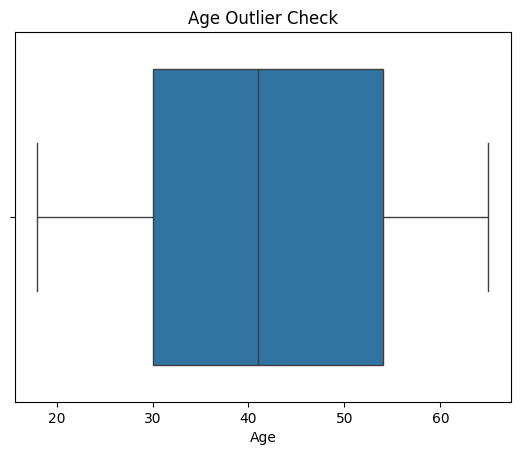

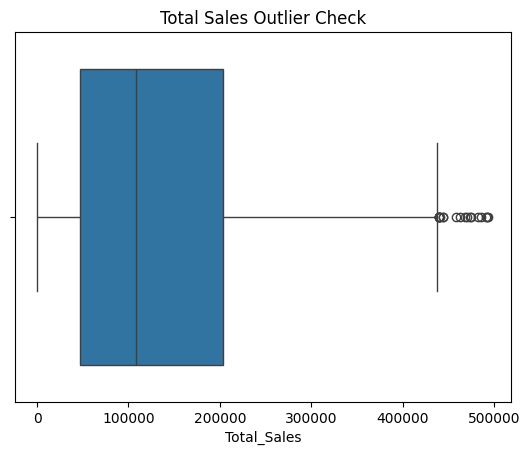

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Example: Age column
sns.boxplot(x=Data['Age'])
plt.title('Age Outlier Check')
plt.show()

# Example: Total_Sales column
sns.boxplot(x=Data['Total_Sales'])
plt.title('Total Sales Outlier Check')
plt.show()


In [13]:
# Fill missing numeric values with median
Data['Age'] = Data['Age'].fillna(Data['Age'].median())

# Fill missing categorical values with 'Unknown'
for col in ['City']:
    Data[col] = Data[col].fillna('Unknown')




In [14]:
# Convert Order_Date to datetime
Data['Order_Date'] = pd.to_datetime(Data['Order_Date'], errors='coerce')

# Extract useful features
Data['Order_Year'] = Data['Order_Date'].dt.year
Data['Order_Month'] = Data['Order_Date'].dt.month
Data['Order_Day'] = Data['Order_Date'].dt.day


In [15]:


# Create Age Groups
Data['Age_Group'] = pd.cut(Data['Age'],
                           bins=[0,18,30,45,60,100],
                           labels=['Teen','Young Adult','Adult','Middle Age','Senior'])




In [16]:
print("Final shape:", Data.shape)
display(Data.head())
print(Data.isnull().sum())

Final shape: (1000, 16)


,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Order_Year,Order_Month,Order_Day,Age_Group
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,2025,2,25,Young Adult
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80,2025,10,14,Senior
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48,2025,5,13,Senior
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,2025,12,2,Senior
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,2025,11,20,Adult


Order_ID         0
Order_Date       0
Customer_ID      0
Customer_Name    0
Age              0
Gender           0
City             0
Product          0
Category         0
Quantity         0
Unit_Price       0
Total_Sales      0
Order_Year       0
Order_Month      0
Order_Day        0
Age_Group        0
dtype: int64


In [ ]:
# Save cleaned dataset
Data.to_csv("Cleaned_Sales_Dataset.csv", index=False)

print(" Step 3 complete: Cleaned dataset saved as Cleaned_Sales_Dataset.csv")


 Step 3 complete: Cleaned dataset saved as Cleaned_Sales_Dataset.csv


In [ ]:
from google.colab import files
files.download('Cleaned_Sales_Dataset.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>